In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [27]:
df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv', nrows=20000)

In [28]:
#cleaning for random forest--->focused on block, hour and aarested flage
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Hour'] = df['Date'].dt.hour
df_clean = df.dropna(subset=['Block', 'Hour', 'Arrest'])
df_clean

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Hour
0,11646166,JC213529,2018-09-01 00:01:00,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN,0
1,11645836,JC212333,2016-05-01 00:25:00,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN,0
2,11449702,JB373031,2018-07-31 13:30:00,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN,13
3,11643334,JC209972,2018-12-19 16:30:00,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN,16
4,11645527,JC212744,2015-02-02 10:00:00,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2458564,HH771061,2002-11-10 16:36:04,002XX S HOMAN AVE,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,...,27.0,18,NaN,NaN,2002,08/17/2015 03:03:40 PM,NaN,NaN,NaN,16
19996,1674352,G463880,2001-08-06 07:45:00,049XX W JACKSON BL,0460,BATTERY,SIMPLE,RESIDENCE,False,True,...,NaN,08B,1143726.0,1898262.0,2001,08/17/2015 03:03:40 PM,41.876861,-87.747749,"(41.876860577, -87.74774935)",7
19997,2459307,HH788023,2002-11-15 09:00:00,036XX N LAKE SHORE DR,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,6.0,07,NaN,NaN,2002,08/17/2015 03:03:40 PM,NaN,NaN,NaN,9
19998,1674484,G463799,2001-08-06 06:50:00,040XX N CENTRAL PARK AV,0320,ROBBERY,STRONGARM - NO WEAPON,STREET,False,False,...,NaN,03,1151712.0,1926529.0,2001,08/17/2015 03:03:40 PM,41.954275,-87.717682,"(41.954274519, -87.717681911)",6


In [29]:

crime_counts = df_clean.groupby(['Block', 'Hour']).size().reset_index(name='crime_count')
crime_counts

,Block,Hour,crime_count
0,0000X E 100 ST,3,1
1,0000X E 100TH PL,13,1
2,0000X E 100TH PL,22,1
3,0000X E 100TH ST,12,1
4,0000X E 101ST PL,14,1
...,...,...,...
16162,134XX S BALTIMORE AVE,0,1
16163,134XX S BALTIMORE AVE,4,1
16164,134XX S HOUSTON AVE,12,1
16165,135XX S AVENUE M,0,1


In [30]:
block_total_crimes = df_clean.groupby('Block').size().reset_index(name='block_total_crimes')

block_total_crimes

,Block,block_total_crimes
0,0000X E 100 ST,1
1,0000X E 100TH PL,2
2,0000X E 100TH ST,1
3,0000X E 101ST PL,1
4,0000X E 101ST ST,1
...,...,...
8674,133XX S MACKINAW AVE,2
8675,134XX S BALTIMORE AVE,2
8676,134XX S HOUSTON AVE,1
8677,135XX S AVENUE M,1


In [31]:

crime_counts = crime_counts.merge(block_total_crimes, on='Block')
crime_counts

,Block,Hour,crime_count,block_total_crimes
0,0000X E 100 ST,3,1,1
1,0000X E 100TH PL,13,1,2
2,0000X E 100TH PL,22,1,2
3,0000X E 100TH ST,12,1,1
4,0000X E 101ST PL,14,1,1
...,...,...,...,...
16162,134XX S BALTIMORE AVE,0,1,2
16163,134XX S BALTIMORE AVE,4,1,2
16164,134XX S HOUSTON AVE,12,1,1
16165,135XX S AVENUE M,0,1,1


In [32]:
arrest_rates = df_clean.groupby(['Block', 'Hour'])['Arrest'].apply(
    lambda x: (x == 'Y').sum() / len(x) if len(x) > 0 else 0
).reset_index(name='arrest_rate')
crime_counts = crime_counts.merge(arrest_rates, on=['Block', 'Hour'])
print(f"✓ 特征工程完成，共 {len(crime_counts)} 行数据")
print(f"\n特征统计:")
print(f"  Block 种类: {crime_counts['Block'].nunique()}")
print(f"  Hour 范围: {crime_counts['Hour'].min()}-{crime_counts['Hour'].max()}")
print(f"  逮捕率范围: {crime_counts['arrest_rate'].min():.2f}-{crime_counts['arrest_rate'].max():.2f}")


✓ 特征工程完成，共 16167 行数据

特征统计:
  Block 种类: 8679
  Hour 范围: 0-23
  逮捕率范围: 0.00-0.00


In [33]:
crime_counts = crime_counts.merge(block_total_crimes, on='Block', how='left')
crime_counts = crime_counts.merge(arrest_rates, on=['Block', 'Hour'], how='left') 
crime_counts

,Block,Hour,crime_count,block_total_crimes_x,arrest_rate_x,block_total_crimes_y,arrest_rate_y
0,0000X E 100 ST,3,1,1,0.0,1,0.0
1,0000X E 100TH PL,13,1,2,0.0,2,0.0
2,0000X E 100TH PL,22,1,2,0.0,2,0.0
3,0000X E 100TH ST,12,1,1,0.0,1,0.0
4,0000X E 101ST PL,14,1,1,0.0,1,0.0
...,...,...,...,...,...,...,...
16162,134XX S BALTIMORE AVE,0,1,2,0.0,2,0.0
16163,134XX S BALTIMORE AVE,4,1,2,0.0,2,0.0
16164,134XX S HOUSTON AVE,12,1,1,0.0,1,0.0
16165,135XX S AVENUE M,0,1,1,0.0,1,0.0


In [37]:
le_block = LabelEncoder()
crime_counts['Block_encoded'] = le_block.fit_transform(crime_counts['Block'])
print(f"✓ Block 编码: {crime_counts['Block'].nunique()} 种 → 数字")
crime_counts


✓ Block 编码: 8679 种 → 数字


,Block,Hour,crime_count,block_total_crimes_x,arrest_rate_x,block_total_crimes_y,arrest_rate_y,Block_encoded
0,0000X E 100 ST,3,1,1,0.0,1,0.0,0
1,0000X E 100TH PL,13,1,2,0.0,2,0.0,1
2,0000X E 100TH PL,22,1,2,0.0,2,0.0,1
3,0000X E 100TH ST,12,1,1,0.0,1,0.0,2
4,0000X E 101ST PL,14,1,1,0.0,1,0.0,3
...,...,...,...,...,...,...,...,...
16162,134XX S BALTIMORE AVE,0,1,2,0.0,2,0.0,8675
16163,134XX S BALTIMORE AVE,4,1,2,0.0,2,0.0,8675
16164,134XX S HOUSTON AVE,12,1,1,0.0,1,0.0,8676
16165,135XX S AVENUE M,0,1,1,0.0,1,0.0,8677


In [39]:

X = crime_counts[['Block_encoded', 'Hour', 'arrest_rate_x', 'block_total_crimes_x']]
y = crime_counts['crime_count']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [40]:

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# 计算指标
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\n📊 训练集性能:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\n📊 测试集性能:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")

if test_r2 > 0.7:
    print("\n✅ 模型性能良好 (R² > 0.7)")
elif test_r2 > 0.5:
    print("\n⚠️  模型性能中等 (R² > 0.5)")
else:
    print("\n❌ 模型性能不理想 (R² < 0.5)")



📊 训练集性能:
  RMSE: 0.4184
  MAE:  0.1599
  R²:   0.8540

📊 测试集性能:
  RMSE: 0.6409
  MAE:  0.2360
  R²:   0.6262

⚠️  模型性能中等 (R² > 0.5)



步骤6️⃣: 特征重要性分析
----------------------------------------------------------------------

影响犯罪数量的关键因素 (RQ2答案):
  Block Total Crimes  :  67.5% █████████████████████████████████
  Hour                :  22.8% ███████████
  Block               :   9.7% ████
  Arrest Rate         :   0.0% 

步骤7️⃣: 可视化结果
----------------------------------------------------------------------
✓ 可视化已保存为 'rf_crime_prediction.png'


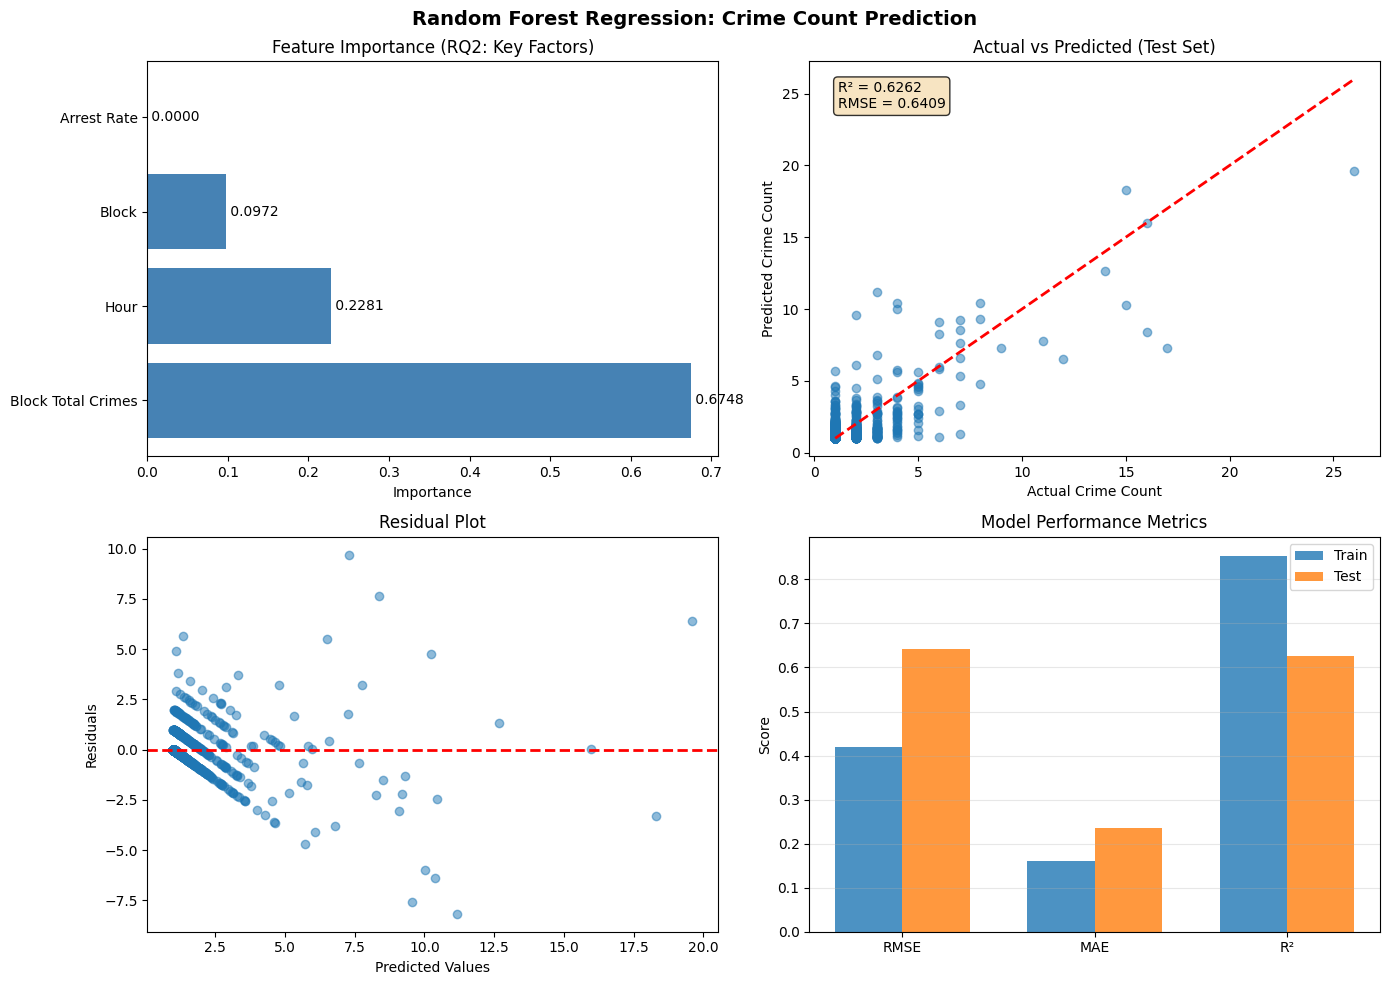


步骤8️⃣: 样本预测
----------------------------------------------------------------------

✅ 所有步骤完成!

📋 总结
----------------------------------------------------------------------

模型: 随机森林回归 (Random Forest Regressor)
数据: 20000 → 16167 (Block×Hour 组合)
特征: Block, Hour, Arrest Rate, Block Total Crimes
目标: 每个Block每小时的犯罪数

性能:
  • 测试集 R² = 0.6262 (模型解释62.6%的方差)
  • 测试集 RMSE = 0.6409 (平均预测误差)

关键发现 (RQ2 - 影响因素):
  1. Block Total Crimes: 67.5%
  2. Hour: 22.8%
  3. Block: 9.7%
  4. Arrest Rate: 0.0%



In [41]:




# ===== 步骤6: 特征重要性分析 (RQ2的答案) =====
print("\n步骤6️⃣: 特征重要性分析")
print("-" * 70)

feature_importance = pd.DataFrame({
    'feature': ['Block', 'Hour', 'Arrest Rate', 'Block Total Crimes'],
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n影响犯罪数量的关键因素 (RQ2答案):")
for idx, row in feature_importance.iterrows():
    pct = row['importance'] * 100
    bar = '█' * int(pct / 2)
    print(f"  {row['feature']:20s}: {pct:5.1f}% {bar}")

# ===== 步骤7: 可视化 =====
print("\n步骤7️⃣: 可视化结果")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest Regression: Crime Count Prediction', fontsize=14, fontweight='bold')

# 图1: 特征重要性
ax1 = axes[0, 0]
ax1.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
ax1.set_xlabel('Importance')
ax1.set_title('Feature Importance (RQ2: Key Factors)')
for i, v in enumerate(feature_importance['importance']):
    ax1.text(v, i, f' {v:.4f}', va='center')

# 图2: 实际 vs 预测
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_test, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Crime Count')
ax2.set_ylabel('Predicted Crime Count')
ax2.set_title('Actual vs Predicted (Test Set)')
ax2.text(0.05, 0.95, f'R² = {test_r2:.4f}\nRMSE = {test_rmse:.4f}',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 图3: 残差分析
ax3 = axes[1, 0]
residuals = y_test - y_pred_test
ax3.scatter(y_pred_test, residuals, alpha=0.5)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residual Plot')

# 图4: 模型性能对比
ax4 = axes[1, 1]
metrics = ['RMSE', 'MAE', 'R²']
train_vals = [train_rmse, train_mae, train_r2]
test_vals = [test_rmse, test_mae, test_r2]

x = np.arange(len(metrics))
width = 0.35

ax4.bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
ax4.bar(x + width/2, test_vals, width, label='Test', alpha=0.8)
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Metrics')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_crime_prediction.png', dpi=300, bbox_inches='tight')
print("✓ 可视化已保存为 'rf_crime_prediction.png'")
plt.show()

# ===== 步骤8: 样本预测 =====
print("\n步骤8️⃣: 样本预测")
print("-" * 70)

# 预测例子：Block "001", Hour 12, 逮捕率 0.5
sample_block = "001"
sample_hour = 12
sample_arrest_rate = 0.5

if sample_block in le_block.classes_:
    sample_X = pd.DataFrame({
        'Block_encoded': [le_block.transform([sample_block])[0]],
        'Hour': [sample_hour],
        'arrest_rate': [sample_arrest_rate],
        'block_total_crimes': [block_total_crimes[block_total_crimes['Block']==sample_block]['block_total_crimes'].values[0]]
    })
    
    prediction = rf_model.predict(sample_X)[0]
    print(f"\n示例预测:")
    print(f"  Block: {sample_block}")
    print(f"  Hour: {sample_hour}:00")
    print(f"  Arrest Rate: {sample_arrest_rate:.1%}")
    print(f"  预测犯罪数: {prediction:.1f} 起")

print("\n" + "="*70)
print("✅ 所有步骤完成!")
print("="*70)

# ===== 总结 =====
print("\n📋 总结")
print("-" * 70)
print(f"""
模型: 随机森林回归 (Random Forest Regressor)
数据: {len(df)} → {len(crime_counts)} (Block×Hour 组合)
特征: Block, Hour, Arrest Rate, Block Total Crimes
目标: 每个Block每小时的犯罪数

性能:
  • 测试集 R² = {test_r2:.4f} (模型解释{test_r2*100:.1f}%的方差)
  • 测试集 RMSE = {test_rmse:.4f} (平均预测误差)

关键发现 (RQ2 - 影响因素):
  1. {feature_importance.iloc[0]['feature']}: {feature_importance.iloc[0]['importance']*100:.1f}%
  2. {feature_importance.iloc[1]['feature']}: {feature_importance.iloc[1]['importance']*100:.1f}%
  3. {feature_importance.iloc[2]['feature']}: {feature_importance.iloc[2]['importance']*100:.1f}%
  4. {feature_importance.iloc[3]['feature']}: {feature_importance.iloc[3]['importance']*100:.1f}%
""")